# Data Assimilation — Ensemble Kalman Filtering with filterax

Somax models are forward operators; on their own they only *propagate* a
state. **Data assimilation** (DA) corrects that state against noisy, sparse
observations of reality. This tutorial wires a somax
[Lorenz '96](lorenz96_simulation.ipynb) model into
[`filterax`](https://github.com/jejjohnson/filterax) and runs an **Ensemble
Transform Kalman Filter (ETKF)** twin experiment.

**What you'll learn:**

1. The `somax.da` adapters that bridge a somax model to a filterax filter
2. How to set up a *twin experiment* (truth run + synthetic observations)
3. How the analysis tracks the truth far better than a free forecast

```{note}
This tutorial needs the optional `da` dependency group, which provides
`filterax` (and, transitively, `gaussx`):

    uv sync --group da
```

## The `somax.da` bridge

`filterax` filters operate on **flat state vectors** of shape `(N_x,)`,
vectorised over an ensemble `(N_e, N_x)`. somax states are equinox
*pytrees*. Three small adapters span that gap:

| `somax.da` object | Role |
|---|---|
| `SomaxDynamics`   | wrap `model.step` as a `filterax.AbstractDynamics` |
| `SubsampleObs`    | sparse observation operator `H(x) = x[indices]` |
| `state_to_vector` | flatten a state pytree to a vector (+ inverse) |
| `make_ensemble`   | build a perturbed flat ensemble around a state |

Because the dynamics adapter only relies on `model.step(state, dt, *, t0=...)`,
*any* somax model drops in unchanged.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
from filterax import ETKF

from somax.da import SomaxDynamics, SubsampleObs, make_ensemble, state_to_vector
from somax.models import L96State, Lorenz96

## 1. The truth run

We use a 40-variable Lorenz '96 system at $F = 8$ (fully chaotic). The truth
is spun up onto the attractor, then integrated forward in fixed windows of
`dt = 0.05`. This trajectory is what the filter is trying to recover — in a
real problem it is unknown.

In [2]:
key = jax.random.PRNGKey(0)
K = 40  # state dimension
dt = 0.05  # assimilation-window length
n_windows = 40  # number of observation times
n_members = 40  # ensemble size N_e
obs_var = 0.5  # observation-error variance

model = Lorenz96.create(F=8.0)
step = jax.jit(lambda s: model.step(s, dt))

# Spin the truth onto the attractor.
truth = L96State(x=8.0 * jnp.ones(K).at[0].add(0.01))
for _ in range(300):
    truth = step(truth)
truth0 = truth
print("truth spun up:", truth0.x.shape)

truth spun up: (40,)


## 2. Synthetic observations

We observe **every other grid point** (a 50% sparse network) with additive
Gaussian noise of variance `obs_var`. The observation operator is the linear
`SubsampleObs`; its error covariance `R` is a diagonal `lineax` operator.

In [3]:
obs_idx = jnp.arange(0, K, 2)  # observe x[0], x[2], x[4], ...
obs_op = SubsampleObs(indices=obs_idx)
R = lx.DiagonalLinearOperator(obs_var * jnp.ones(obs_idx.size))

truths, observations = [], []
state = truth0
for w in range(1, n_windows + 1):
    state = step(state)
    vec, _ = state_to_vector(state)
    truths.append(vec)
    key, sub = jax.random.split(key)
    noise = jnp.sqrt(obs_var) * jax.random.normal(sub, (obs_idx.size,))
    observations.append((vec[obs_idx] + noise, w * dt))
truths = jnp.stack(truths)  # (T, N_x)
print(f"{len(observations)} observation windows, {obs_idx.size} obs / window")

40 observation windows, 20 obs / window


## 3. Run the ETKF

The ensemble is seeded by perturbing the (known) initial truth — a stand-in
for background uncertainty. `ETKF.assimilate` then loops
`forecast → analysis` over every window. The forecast step is
`SomaxDynamics` (i.e. the somax model) vectorised over the ensemble; the
analysis is filterax's ETKF update.

In [4]:
key, sub = jax.random.split(key)
ensemble0 = make_ensemble(truth0, sub, size=n_members, std=1.0)

etkf = ETKF(dynamics=SomaxDynamics(model=model, template=truth0), obs_op=obs_op)
result = etkf.assimilate(ensemble0, observations, R, t0=0.0)

analysis_mean = result.analysis_history.mean(axis=1)  # (T, N_x)
forecast_mean = result.forecast_history.mean(axis=1)  # (T, N_x)

analysis_rmse = jnp.sqrt(jnp.mean((analysis_mean - truths) ** 2, axis=1))
forecast_rmse = jnp.sqrt(jnp.mean((forecast_mean - truths) ** 2, axis=1))
print(f"mean analysis RMSE: {analysis_rmse.mean():.3f}")
print(f"mean forecast RMSE: {forecast_rmse.mean():.3f}")
print(f"observation-noise floor (sqrt obs_var): {jnp.sqrt(obs_var):.3f}")

mean analysis RMSE: 0.315
mean forecast RMSE: 0.338
observation-noise floor (sqrt obs_var): 0.707


## 4. Does it work?

Two checks. **(a)** the per-window RMSE of the analysis sits below the
forecast and well under the observation-noise floor — the filter extracts
more signal than any single observation carries. **(b)** the analysis
Hovmoller is visually indistinguishable from the truth.

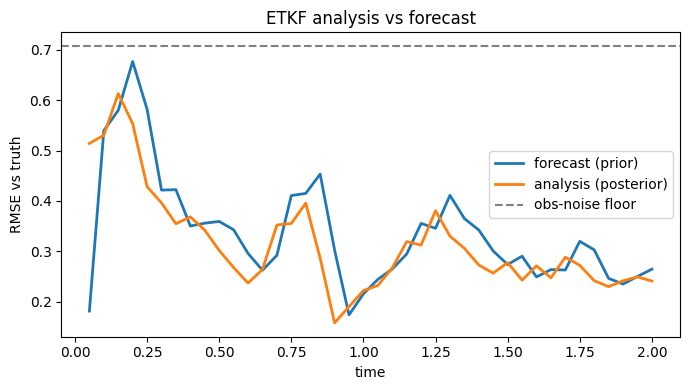

In [5]:
times = jnp.arange(1, n_windows + 1) * dt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(times, forecast_rmse, label="forecast (prior)", lw=2)
ax.plot(times, analysis_rmse, label="analysis (posterior)", lw=2)
ax.axhline(float(jnp.sqrt(obs_var)), ls="--", c="grey", label="obs-noise floor")
ax.set(xlabel="time", ylabel="RMSE vs truth", title="ETKF analysis vs forecast")
ax.legend()
fig.tight_layout()
plt.show()

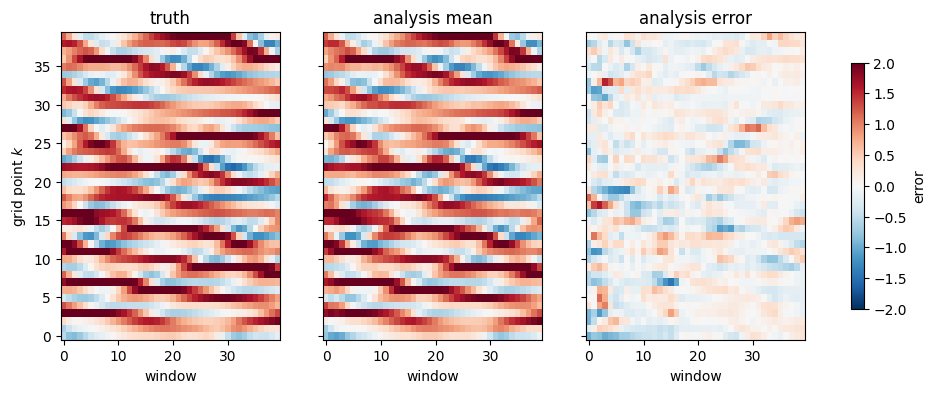

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
kw = dict(aspect="auto", cmap="RdBu_r", vmin=-8, vmax=8, origin="lower")
axes[0].imshow(truths.T, **kw)
axes[0].set(title="truth", xlabel="window", ylabel="grid point $k$")
axes[1].imshow(analysis_mean.T, **kw)
axes[1].set(title="analysis mean", xlabel="window")
im = axes[2].imshow(
    (analysis_mean - truths).T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    origin="lower",
)
axes[2].set(title="analysis error", xlabel="window")
fig.colorbar(im, ax=axes, shrink=0.8, label="error")
plt.show()

## Summary

- `somax.da` provides the thin adapter layer (`SomaxDynamics`,
  `SubsampleObs`, `state_to_vector`, `make_ensemble`) that lets **any**
  somax model be driven by a `filterax` ensemble filter.
- In a Lorenz '96 twin experiment the ETKF analysis tracks the truth with
  RMSE **below both the free forecast and the observation-noise floor**,
  from sparse (50%) noisy observations.
- The same pattern works for the shallow-water and QG models — swap the
  model and the `template` state; the bridge is unchanged.

Variational assimilation (vardax 4DVar) with structured `gaussx`
background/observation covariances builds on the same `somax.da` surface.